In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

In [3]:
df = pd.read_csv("datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: str


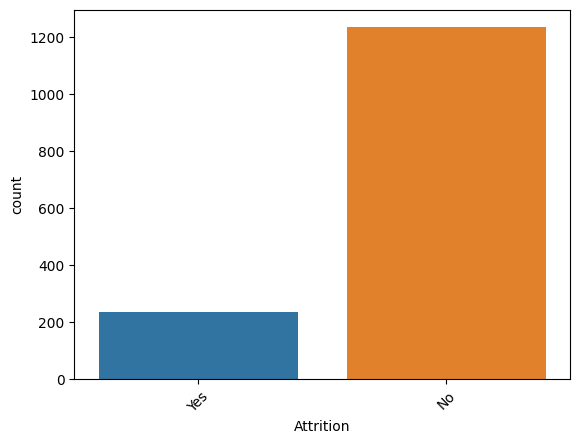

In [5]:
column = 'Attrition'
print(df[column].head())
sns.countplot(df, x=column, hue='Attrition')
plt.xticks(rotation=45)
plt.show()

In [477]:
df.drop(columns=['Gender', 'EmployeeCount', 'StandardHours', 'EmployeeNumber', 'PerformanceRating', 'Over18'], inplace=True)
# df = df[['MonthlyIncome', 'Age', 'OverTime', 'DailyRate', 'TotalWorkingYears', 'HourlyRate', 'YearsAtCompany', 'Attrition']]
# df = df[['MonthlyIncome', 'OverTime', 'Age', 'HourlyRate', 'DistanceFromHome', 'DailyRate', 'MonthlyRate', 'Attrition']]

# df = df[['OverTime', 'DailyRate', 'Age', 'HourlyRate', 'MonthlyIncome', 'YearsWithCurrManager', 
#          'JobLevel', 'EnvironmentSatisfaction', 'MaritalStatus', 'JobSatisfaction', 'YearsAtCompany', 
#          'YearsInCurrentRole', 'DistanceFromHome', 'PercentSalaryHike', 'TrainingTimesLastYear', 
#          'Department', 'YearsSinceLastPromotion', 'JobInvolvement', 'StockOptionLevel', 'Attrition']]

In [478]:
numeric_df = df.select_dtypes(include="number")
numeric_df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
numeric_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   DailyRate                 1470 non-null   int64
 2   DistanceFromHome          1470 non-null   int64
 3   Education                 1470 non-null   int64
 4   EnvironmentSatisfaction   1470 non-null   int64
 5   HourlyRate                1470 non-null   int64
 6   JobInvolvement            1470 non-null   int64
 7   JobLevel                  1470 non-null   int64
 8   JobSatisfaction           1470 non-null   int64
 9   MonthlyIncome             1470 non-null   int64
 10  MonthlyRate               1470 non-null   int64
 11  NumCompaniesWorked        1470 non-null   int64
 12  PercentSalaryHike         1470 non-null   int64
 13  RelationshipSatisfaction  1470 non-null   int64
 14  StockOptionLevel          1470 non-null   int64
 15

<Axes: >

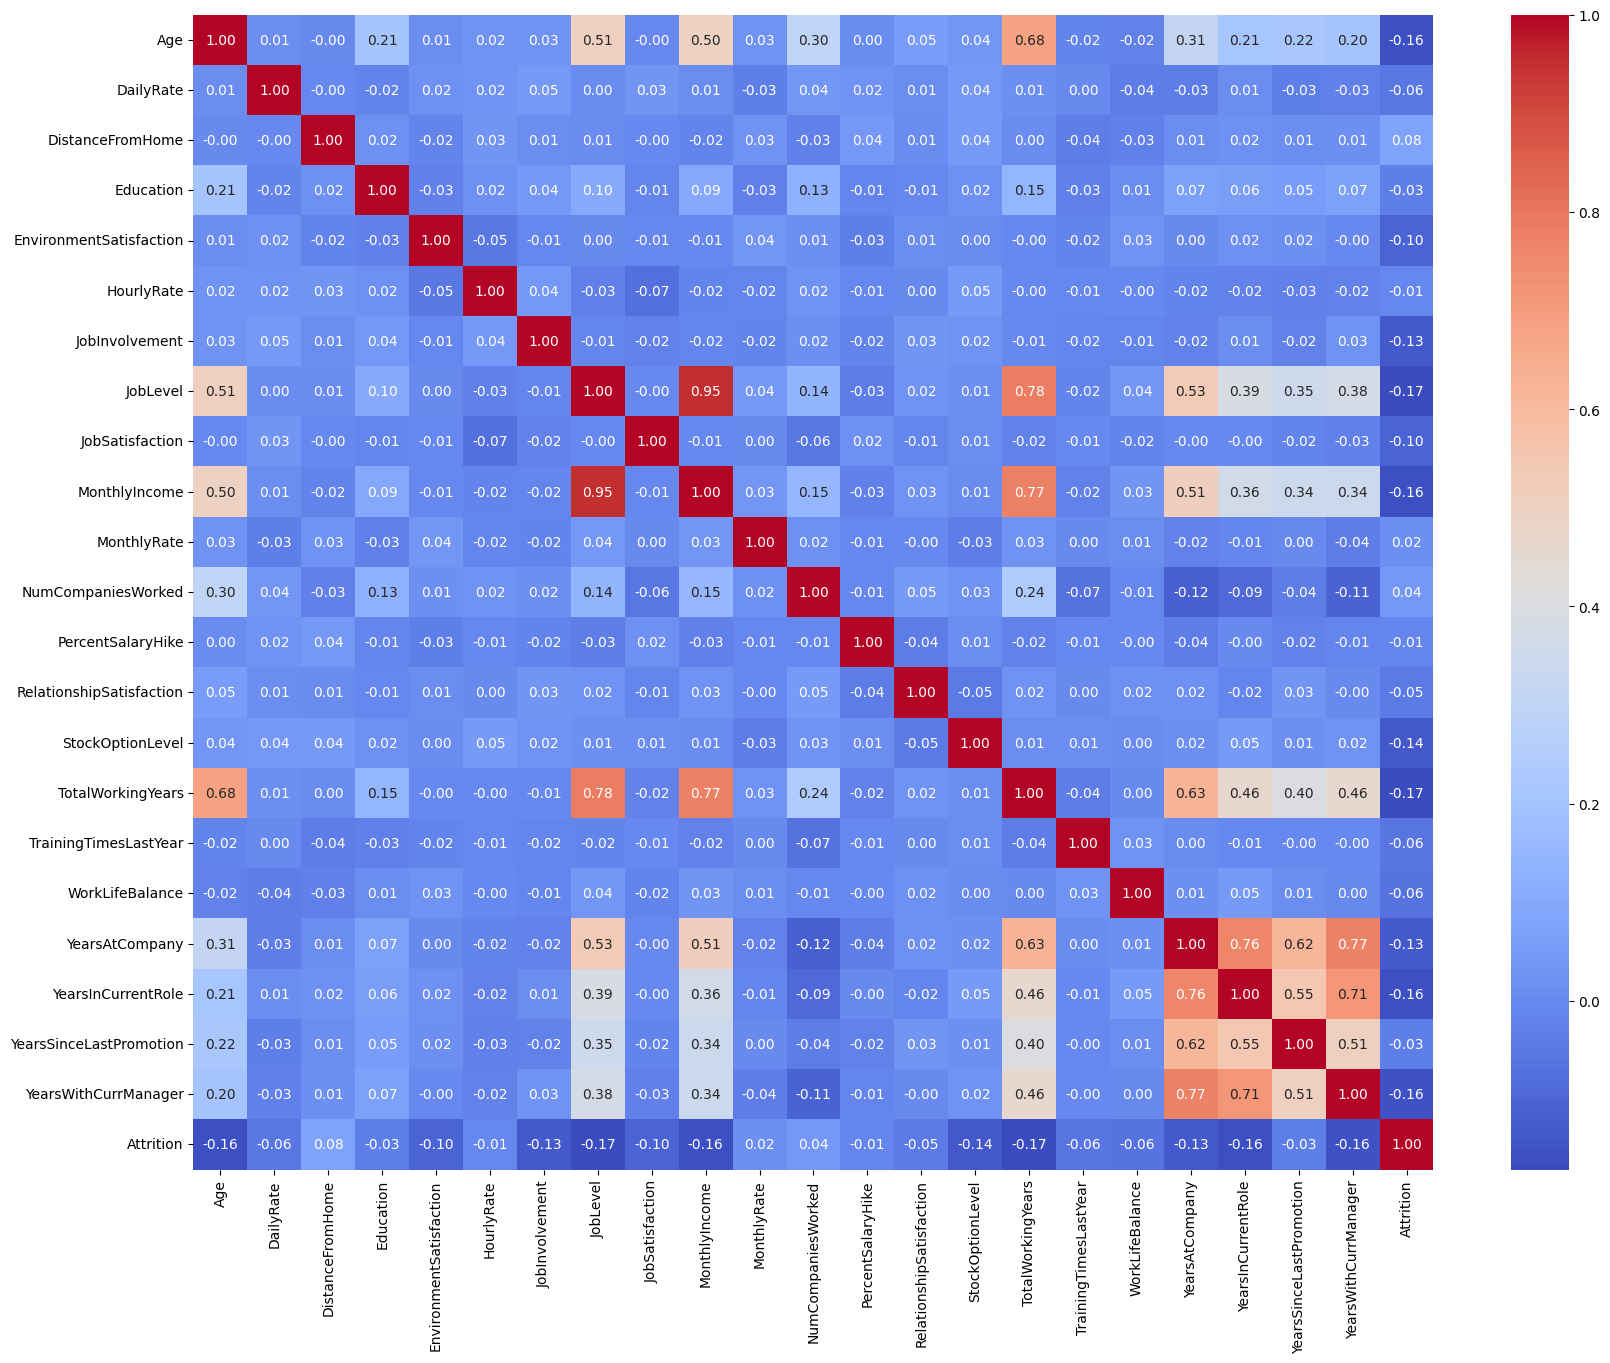

In [479]:
plt.figure(figsize=(20, 15))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [480]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   HourlyRate                1470 non-null   int64
 10  JobInvolvement            1470 non-null   int64
 11  JobLevel                  1470 non-null   int64
 12  JobRole                   1470 non-null   str  
 13  JobSatisfaction           1470 non-null   int64
 14  MaritalStatus             1470 non-null   str  
 15

In [481]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [482]:
df_encoded = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'], 
                            dtype=int)

In [483]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked             

In [484]:

# df_encoded = df
df_encoded = df_encoded[['MonthlyIncome', 'OverTime', 'DailyRate', 'Age', 'StockOptionLevel', 'DistanceFromHome', 
                         'NumCompaniesWorked', 'YearsAtCompany', 'HourlyRate', 'RelationshipSatisfaction', 'JobInvolvement', 
                         'JobSatisfaction', 'TrainingTimesLastYear', 'TotalWorkingYears', 'JobRole_Sales Executive', 
                         'YearsSinceLastPromotion', 'YearsWithCurrManager', 'PercentSalaryHike', 'BusinessTravel_Travel_Rarely', 
                         'BusinessTravel_Travel_Frequently', 'EducationField_Technical Degree', 'MonthlyRate', 
                         'JobRole_Healthcare Representative', 'YearsInCurrentRole', 'EducationField_Marketing', 'Education', 
                         'JobRole_Research Scientist', 'Attrition']]

In [485]:
X = df_encoded.drop(columns='Attrition')
y = df_encoded['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
print(f"{y_test.sum()} / {len(y_test)}")

49 / 294


In [486]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [465]:
model = DecisionTreeClassifier(max_depth=20, class_weight={0:1, 1:5})
model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       246
           1       0.22      0.23      0.22        48

    accuracy                           0.74       294
   macro avg       0.53      0.54      0.53       294
weighted avg       0.75      0.74      0.74       294



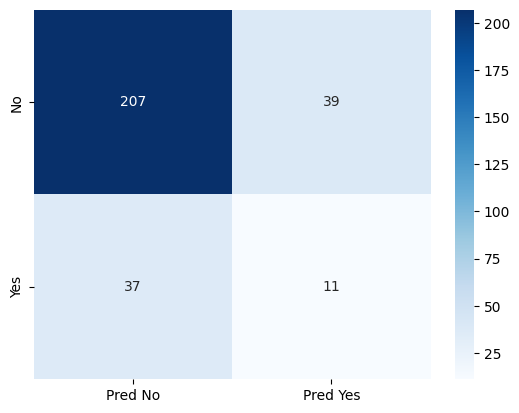

In [466]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', xticklabels=["Pred No", "Pred Yes"], yticklabels=["No", "Yes"])
plt.show()

In [514]:
rf = RandomForestClassifier(n_estimators=150, bootstrap=True,
                            random_state=37, class_weight={0:1, 1:5}, min_samples_leaf=.01)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",0.01
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       245
           1       0.52      0.55      0.53        49

    accuracy                           0.84       294
   macro avg       0.71      0.72      0.72       294
weighted avg       0.84      0.84      0.84       294



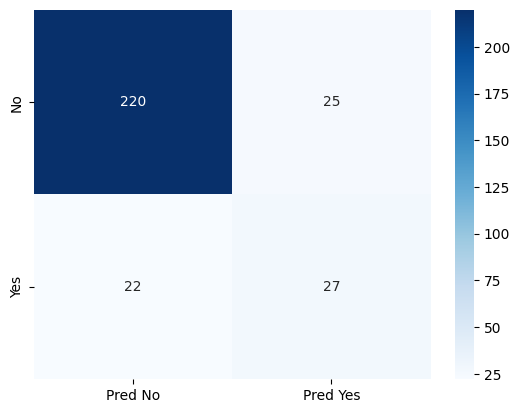

In [520]:
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', xticklabels=["Pred No", "Pred Yes"], yticklabels=["No", "Yes"])
plt.show()

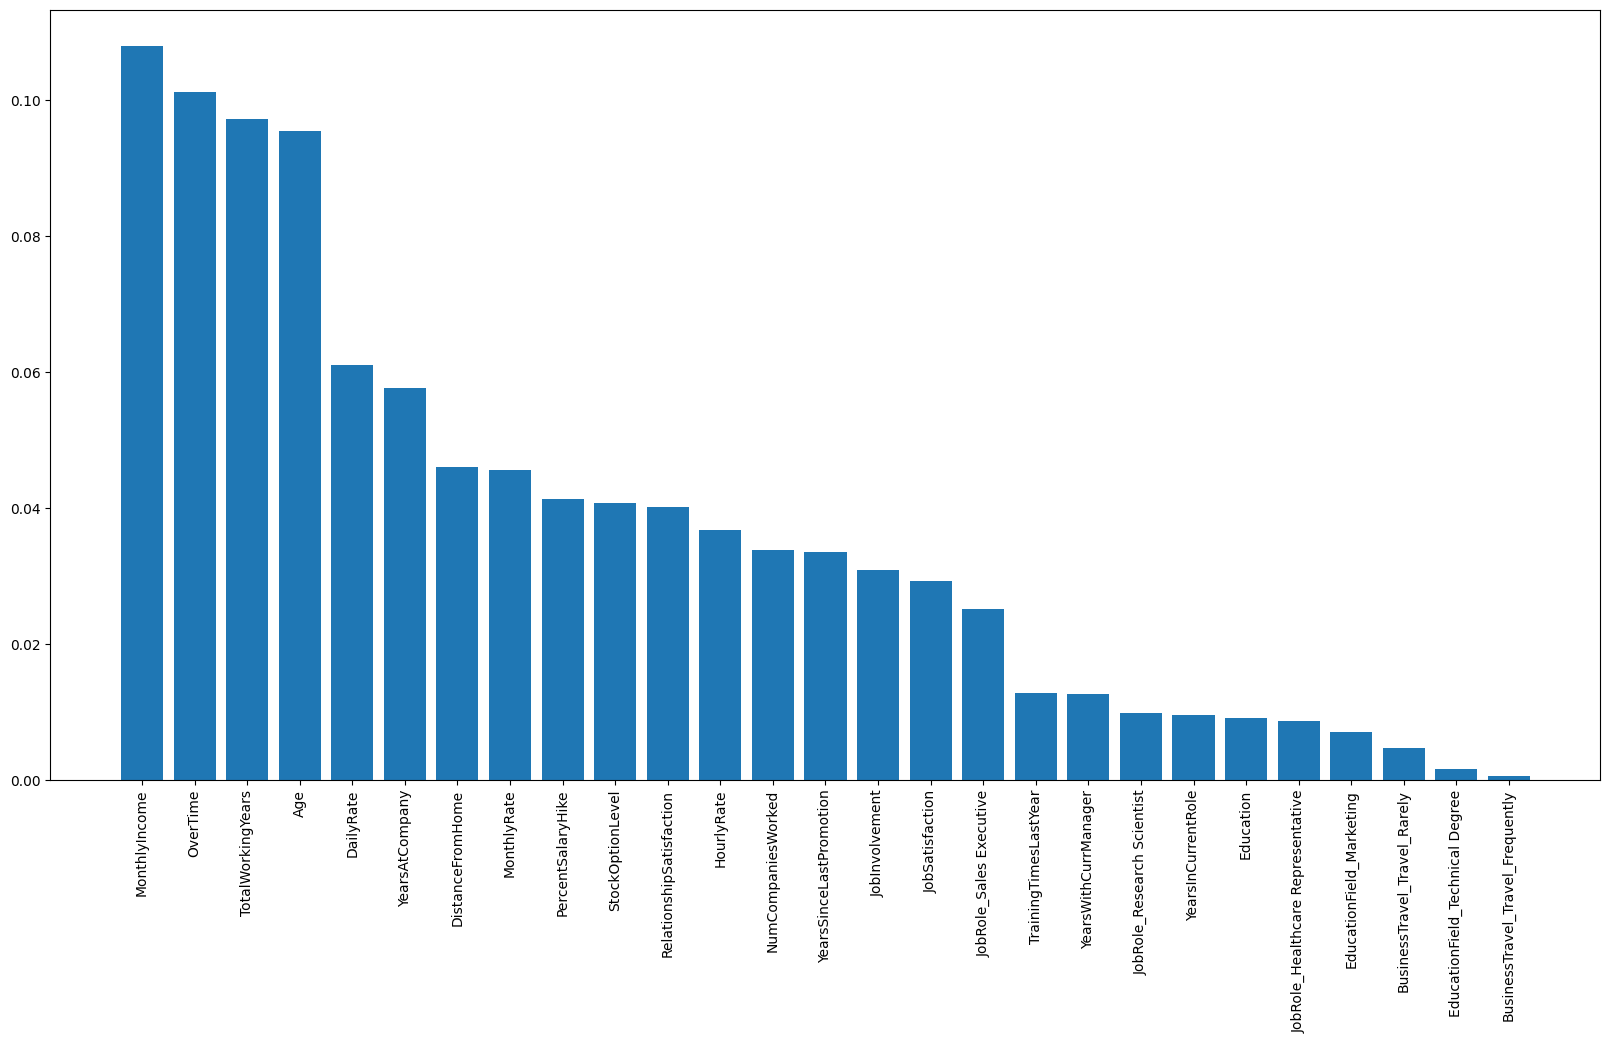

Top features Decision Tree:
MonthlyIncome: 0.1079
OverTime: 0.1012
TotalWorkingYears: 0.0972
Age: 0.0955
DailyRate: 0.0611
YearsAtCompany: 0.0577
DistanceFromHome: 0.0461
MonthlyRate: 0.0456
PercentSalaryHike: 0.0413
StockOptionLevel: 0.0407
RelationshipSatisfaction: 0.0402
HourlyRate: 0.0368
NumCompaniesWorked: 0.0338
YearsSinceLastPromotion: 0.0335
JobInvolvement: 0.0308
JobSatisfaction: 0.0292
JobRole_Sales Executive: 0.0251
TrainingTimesLastYear: 0.0128
YearsWithCurrManager: 0.0126
JobRole_Research Scientist: 0.0099
YearsInCurrentRole: 0.0096
Education: 0.0091
JobRole_Healthcare Representative: 0.0086
EducationField_Marketing: 0.0070
BusinessTravel_Travel_Rarely: 0.0046
EducationField_Technical Degree: 0.0016
BusinessTravel_Travel_Frequently: 0.0005


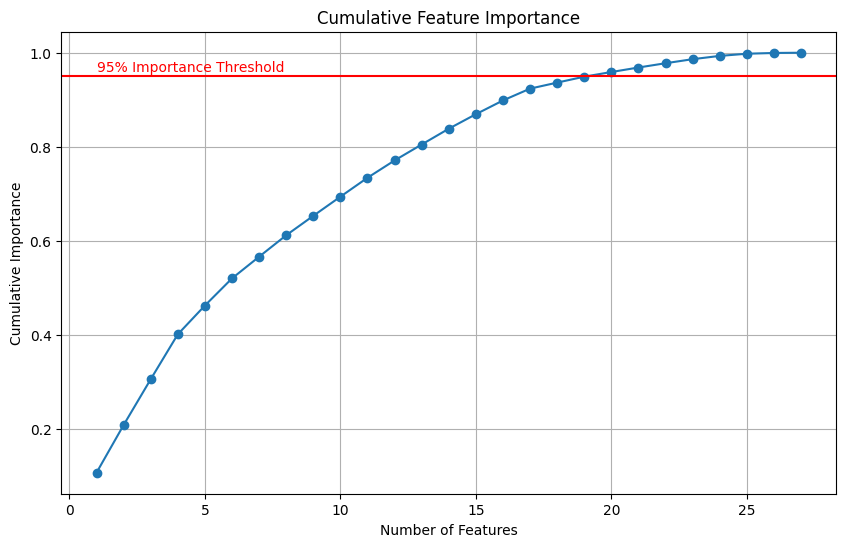


Number of features needed for 95% importance: 20 out of 27


In [469]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(20, 10))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [X.columns[i] for i in indices], rotation=90)
plt.show()

features = []
print(f"Top features Decision Tree:")
for i in range(27):
    features.append(X.columns[indices[i]])
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# print(features)

cumulative_importance = np.cumsum(importances[indices])
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Importance Threshold', color='red')
plt.grid(True)
plt.show()

# Find how many features needed for 95% of importance
n_features_95 = np.where(cumulative_importance >= 0.95)[0][0] + 1
print(f"\nNumber of features needed for 95% importance: {n_features_95} out of {len(X.columns)}")
# #added during screencast

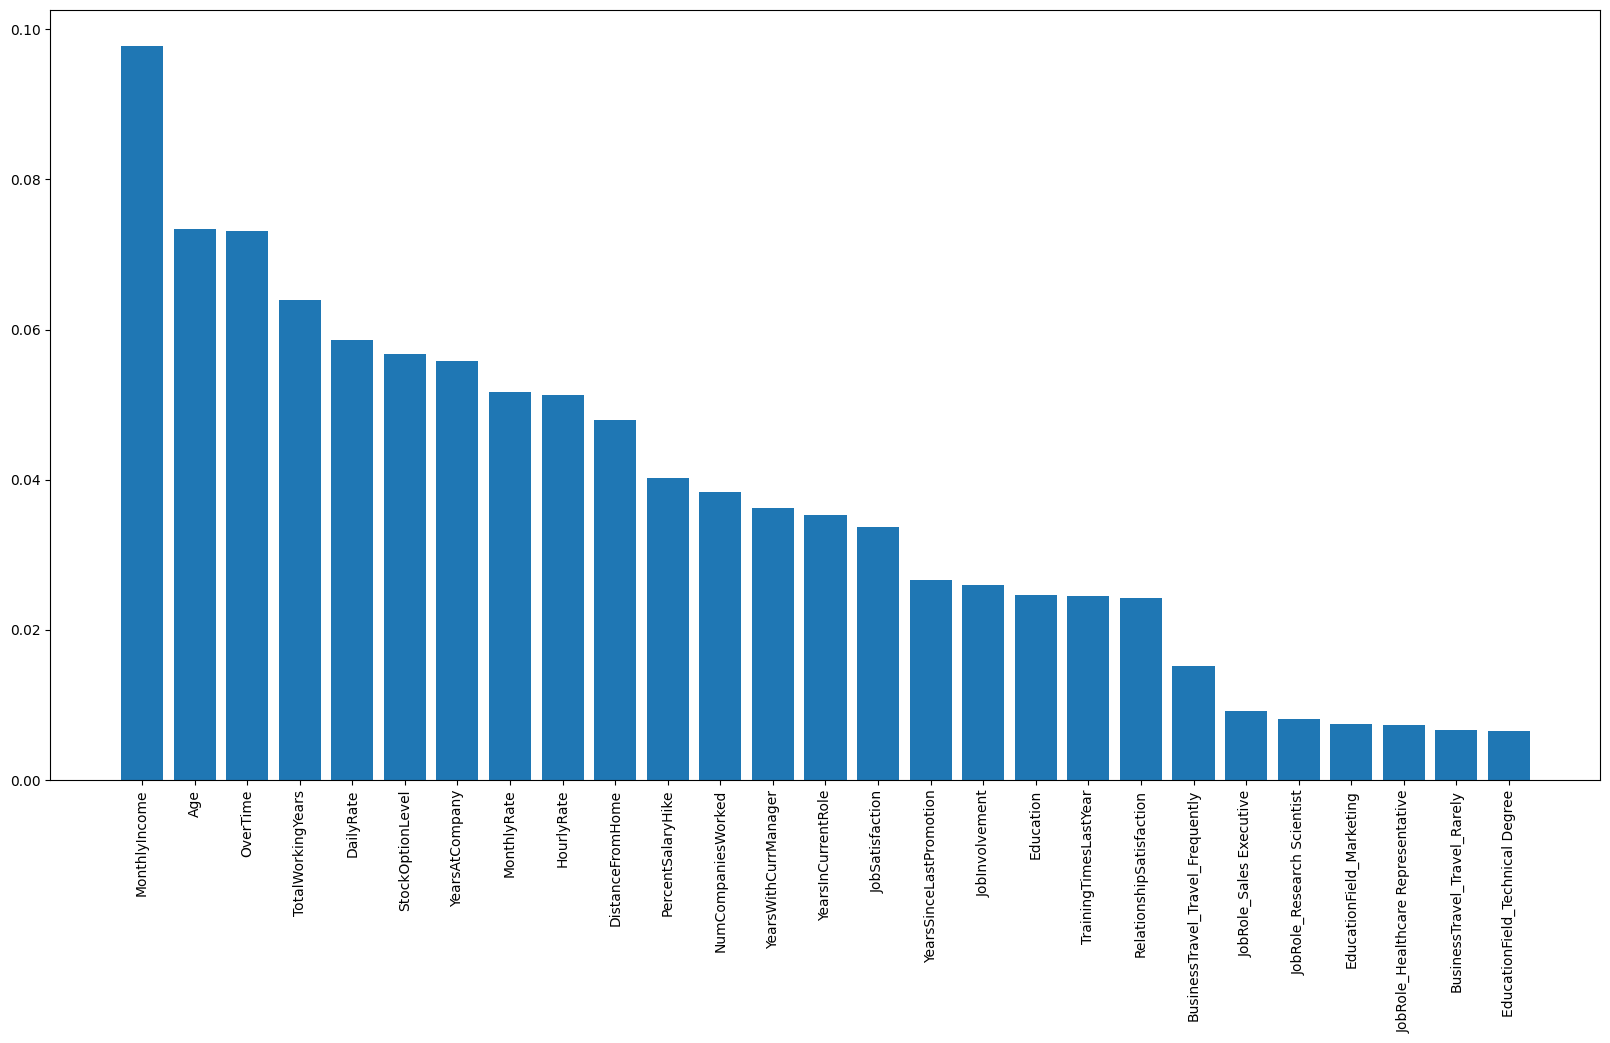

Top features Random Forest:
MonthlyIncome: 0.0977
Age: 0.0734
OverTime: 0.0731
TotalWorkingYears: 0.0640
DailyRate: 0.0585
StockOptionLevel: 0.0568
YearsAtCompany: 0.0558


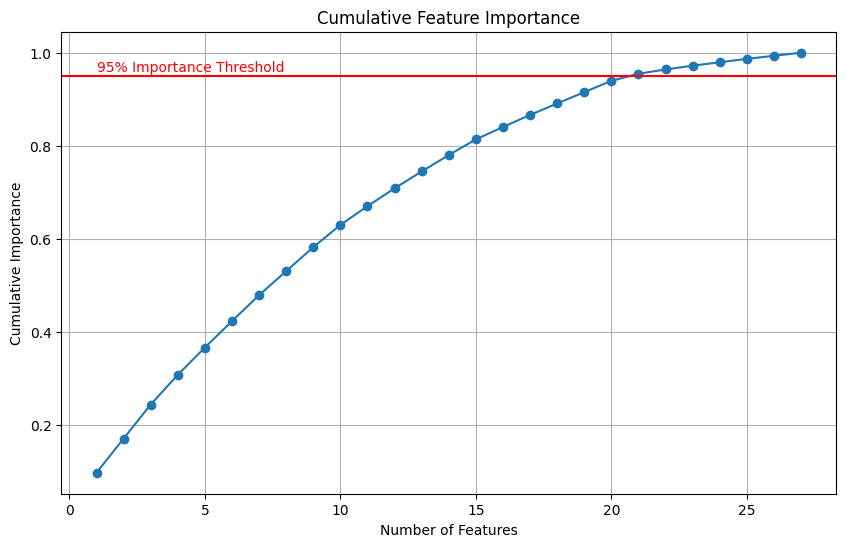


Number of features needed for 95% importance: 21 out of 27


In [470]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(20, 10))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [X.columns[i] for i in indices], rotation=90)
plt.show()

print(f"Top features Random Forest:")
for i in range(7):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

cumulative_importance = np.cumsum(importances[indices])
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Importance Threshold', color='red')
plt.grid(True)
plt.show()

# Find how many features needed for 95% of importance
n_features_95 = np.where(cumulative_importance >= 0.95)[0][0] + 1
print(f"\nNumber of features needed for 95% importance: {n_features_95} out of {len(X.columns)}")
# #added during screencast